# Introduction to Computer Vision: Plant Seedlings Classification

## Problem Statement

### Context

In recent times, the field of agriculture has been in urgent need of modernizing, since the amount of manual work people need to put in to check if plants are growing correctly is still highly extensive. Despite several advances in agricultural technology, people working in the agricultural industry still need to have the ability to sort and recognize different plants and weeds, which takes a lot of time and effort in the long term. The potential is ripe for this trillion-dollar industry to be greatly impacted by technological innovations that cut down on the requirement for manual labor, and this is where Artificial Intelligence can actually benefit the workers in this field, as **the time and energy required to identify plant seedlings will be greatly shortened by the use of AI and Deep Learning.** The ability to do so far more efficiently and even more effectively than experienced manual labor, could lead to better crop yields, the freeing up of human inolvement for higher-order agricultural decision making, and in the long term will result in more sustainable environmental practices in agriculture as well.


### Objective

The aim of this project is to Build a Convolutional Neural Netowrk to classify plant seedlings into their respective categories.

### Data Dictionary

The Aarhus University Signal Processing group, in collaboration with the University of Southern Denmark, has recently released a dataset containing **images of unique plants belonging to 12 different species.**

- The dataset can be download from Olympus.
- The data file names are:
    - images.npy
    - Labels.csv
- Due to the large volume of data, the images were converted to the images.npy file and the labels are also put into Labels.csv, so that you can work on the data/project seamlessly without having to worry about the high data volume.

- The goal of the project is to create a classifier capable of determining a plant's species from an image.

**List of Species**

- Black-grass
- Charlock
- Cleavers
- Common Chickweed
- Common Wheat
- Fat Hen
- Loose Silky-bent
- Maize
- Scentless Mayweed
- Shepherds Purse
- Small-flowered Cranesbill
- Sugar beet

### **Note: Please use GPU runtime on Google Colab to execute the code faster.**

## **Please read the instructions carefully before starting the project.**

This is a commented Python Notebook file in which all the instructions and tasks to be performed are mentioned.

* Blanks '_______' are provided in the notebook that need to be filled with an appropriate code to get the correct result

* With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space

* Identify the task to be performed correctly and only then proceed to write the required code

* Fill the code wherever asked by the commented lines like "# write your code here" or "# complete the code"

* Running incomplete code may throw an error

* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors

* Add the results/observations derived from the analysis in the presentation and submit the same in .pdf format

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
!pip install tensorflow==2.15.0 scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 opencv-python==4.8.0.76 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.8/294.8 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 7.7 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you pref

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
#!pip install tensorflow==2.13.0 scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 opencv-python==4.8.0.76 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [8]:
import os
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2                                                                                       # Importing openCV for image processing
import seaborn as sns                                                                            # Importing seaborn to plot graphs


# Tensorflow modules
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix                                                     # Importing confusion_matrix to plot the confusion matrix
from sklearn.preprocessing import LabelBinarizer
# Display images using OpenCV
from google.colab.patches import cv2_imshow                                                      # Importing cv2_imshow from google.patches to display images
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend
from keras.callbacks import ReduceLROnPlateau
import random
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [ ]:
# Uncomment and run the below code if you are using google colab
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
from google.colab import files
uploaded = files.upload()

Saving images.npy to images.npy


In [9]:
import pandas as pd
import io
# Load the image file of dataset
# The previous code used `np.load()` with a path
# We now need to load the file from the uploaded dictionary.
images = np.load(io.BytesIO(uploaded['images.npy']), allow_pickle=True)

In [10]:
from google.colab import files
uploaded = files.upload()

Saving Labels.csv to Labels (1).csv


In [13]:
# Load the labels file of dataset
#labels = pd.read_csv('______')  # Complete the code to read the dataset
import io

# Replace 'your_file.csv' with the name of your CSV file
labels = pd.read_csv(io.BytesIO(uploaded['Labels (1).csv']))

## Data Overview

### Understand the shape of the dataset

In [14]:
print(images.shape)         # Complete the code to check the shape
print(labels.shape)         # Complete the code to check the shape

(4750, 128, 128, 3)
(4750, 1)


## Exploratory Data Analysis

### Plotting random images from each of the class

In [15]:
def plot_images(images,labels):
  num_classes=10                                                                  # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['Label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index, :])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

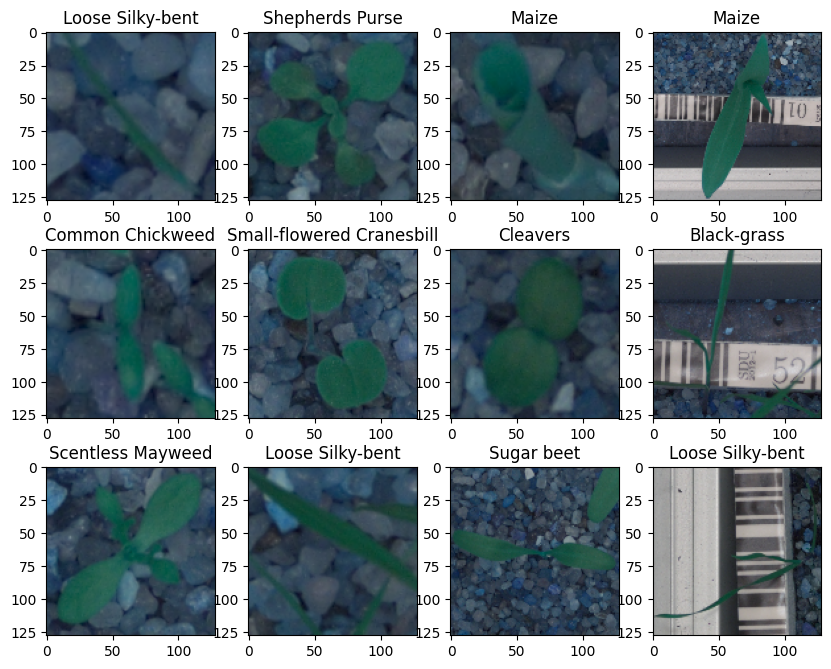

In [16]:
plot_images(images,labels)  # Complete the code to input the images and labels to the function and plot the images with their labels

### Checking the distribution of the target variable

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Small-flowered Cranesbill'),
  Text(1, 0, 'Fat Hen'),
  Text(2, 0, 'Shepherds Purse'),
  Text(3, 0, 'Common wheat'),
  Text(4, 0, 'Common Chickweed'),
  Text(5, 0, 'Charlock'),
  Text(6, 0, 'Cleavers'),
  Text(7, 0, 'Scentless Mayweed'),
  Text(8, 0, 'Sugar beet'),
  Text(9, 0, 'Maize'),
  Text(10, 0, 'Black-grass'),
  Text(11, 0, 'Loose Silky-bent')])

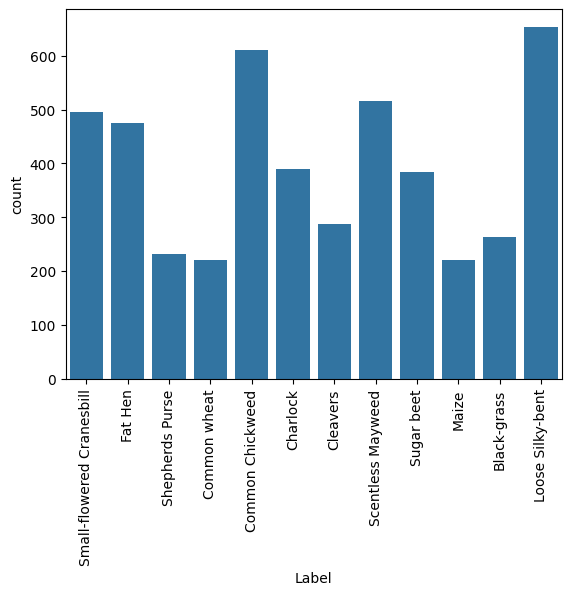

In [17]:
sns.countplot(x=labels['Label'])            # Complete the code to check for data imbalance
plt.xticks(rotation='vertical')

## Data Pre-Processing

### Converting the BGR images to RGB images.

In [18]:
# Converting the images from BGR to RGB using cvtColor function of OpenCV
for i in range(len(images)):
  images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)        # Complete the code to convert the images from BGR to RGB

### Resizing images

As the size of the images is large, it may be computationally expensive to train on these larger images; therefore, it is preferable to reduce the image size from 128 to 64.

In [19]:
images_decreased=[]
height = 64                    # Complete the code to define the height as 64
width =  64                    # Complete the code to define the width as 64
dimensions = (width, height)
for i in range(len(images)):
  images_decreased.append( cv2.resize(images[i], dimensions, interpolation=cv2.INTER_LINEAR))

**Image before resizing**

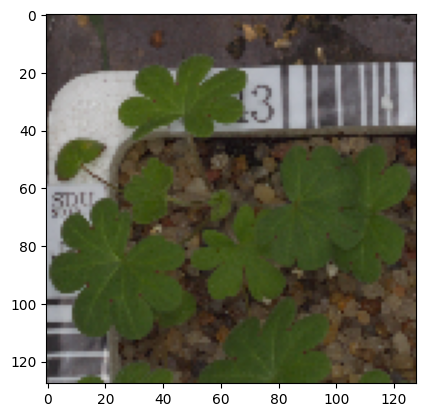

In [20]:
plt.imshow(images[3])

**Image after resizing**

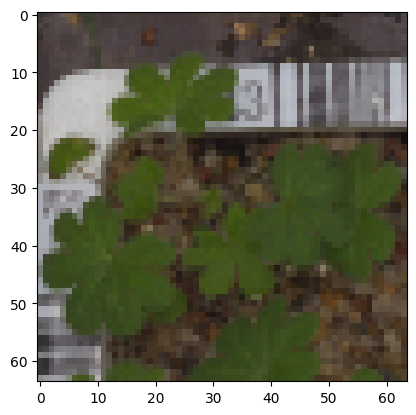

In [21]:
plt.imshow(images_decreased[3])

### Data Preparation for Modeling


- As we have less images in our dataset, we will only use 10% of our data for testing, 10% of our data for validation and 80% of our data for training.
- We are using the train_test_split() function from scikit-learn. Here, we split the dataset into three parts, train,test and validation.

In [22]:
# X_temp, X_test, y_temp, y_test = train_test_split(np.array(images_decreased),______ , test_size=______, random_state=42,stratify=labels)   # Complete the code to split the data with test_size as 0.1
# X_train, X_val, y_train, y_val = train_test_split(______,______ , test_size=______, random_state=42,stratify=y_temp)    # Complete the code to split the data with test_size as 0.1

X_temp, X_test, y_temp, y_test = train_test_split(np.array(images_decreased),labels , test_size=0.1, random_state=42,stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp , test_size=0.1, random_state=42,stratify=y_temp)


In [23]:
# Complete the code to check the shape of train, validation and test data
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(3847, 64, 64, 3) (3847, 1)
(428, 64, 64, 3) (428, 1)
(475, 64, 64, 3) (475, 1)


### Encoding the target labels

In [24]:
# Convert labels from names to one hot vectors.
# We have already used encoding methods like onehotencoder and labelencoder earlier so now we will be using a new encoding method called labelBinarizer.
# Labelbinarizer works similar to onehotencoder

# enc = ______                                        # Complete the code to intialize the labelBinarizer
# y_train_encoded = enc.fit_transform(______)        # Complete the code to fit and transform y_train
# y_val_encoded=enc.transform(______)                  # Complete the code to transform y_val
# y_test_encoded=enc.transform(______)                # Complete the code to transform y_test

enc = LabelBinarizer()
y_train_encoded = enc.fit_transform(y_train)
y_val_encoded=enc.transform(y_val)
y_test_encoded=enc.transform(y_test)



In [25]:
#y_train_encoded.shape,______.shape,______.shape    # Complete the code to check the shape of train, validation and test data
# print(y_train_encoded.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)(3847, 12) (428, 64, 64, 3) (428, 1) (475, 64, 64, 3) (475, 1)
print(y_train_encoded.shape, y_val.shape, y_test.shape)


(3847, 12) (428, 1) (475, 1)


### Data Normalization

Since the **image pixel values range from 0-255**, our method of normalization here will be **scaling** - we shall **divide all the pixel values by 255 to standardize the images to have values between 0-1.**

In [27]:
# Complete the code to normalize the image pixels of train, test and validation data
# X_train_normalized = ______.astype('float32')/255.0
# X_val_normalized = X_val.astype('float32')/______
# X_test_normalized = ______.astype('float32')/255.0

# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

print(X_train_normalized, X_val_normalized, X_test_normalized)

[[[[0.2        0.18431373 0.14901961]
   [0.22352941 0.21568628 0.1882353 ]
   [0.22745098 0.22352941 0.19215687]
   ...
   [0.10588235 0.07058824 0.06666667]
   [0.09019608 0.04705882 0.03921569]
   [0.10588235 0.0627451  0.05098039]]

  [[0.21568628 0.19607843 0.16470589]
   [0.20392157 0.2        0.16862746]
   [0.23921569 0.23921569 0.20392157]
   ...
   [0.10196079 0.0627451  0.05490196]
   [0.11764706 0.08235294 0.07450981]
   [0.11372549 0.07450981 0.06666667]]

  [[0.20784314 0.17254902 0.14901961]
   [0.20784314 0.18039216 0.15686275]
   [0.23137255 0.22352941 0.1882353 ]
   ...
   [0.10588235 0.05490196 0.04705882]
   [0.10588235 0.05490196 0.05098039]
   [0.11372549 0.06666667 0.06666667]]

  ...

  [[0.28627452 0.19215687 0.13725491]
   [0.34509805 0.2627451  0.19215687]
   [0.33333334 0.25882354 0.16862746]
   ...
   [0.34117648 0.28627452 0.24705882]
   [0.32941177 0.26666668 0.21960784]
   [0.30980393 0.24705882 0.20784314]]

  [[0.33333334 0.25882354 0.2       ]
   [0.3

## Model Building

In [28]:
# Clearing backend
backend.clear_session()

In [22]:
# Fixing the seed for random number generators
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [24]:
# Intializing a sequential model
# model1 = ______                             # Complete the code to intialize a sequential model

# # Complete the code to add the first conv layer with 128 filters and kernel size 3x3 , padding 'same' provides the output size same as the input size
# # Input_shape denotes input image dimension of images
# model1.add(Conv2D(______, (3, 3), activation='______', padding="same", input_shape=(64, 64, 3)))

# # Complete the code to add the max pooling to reduce the size of output of first conv layer
# model1.add(______((2, 2), padding = 'same'))

# # Complete the code to create two similar convolution and max-pooling layers activation = relu
# model1.add(Conv2D(64, (3, 3), activation='______', padding="same"))
# model1.add(______((2, 2), padding = 'same'))

# model1.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
# model1.add(MaxPooling2D((2, 2), padding = 'same'))

# # Complete the code to flatten the output of the conv layer after max pooling to make it ready for creating dense connections
# model1.add(______())

# # Complete the code to add a fully connected dense layer with 16 neurons
# model1.add(Dense(______, activation='relu'))
# model1.add(Dropout(0.3))
# # Complete the code to add the output layer with 12 neurons and activation functions as softmax since this is a multi-class classification problem
# model1.add(Dense(______, activation='softmax'))

# # Complete the code to use the Adam Optimizer
# opt=Adam()
# # Complete the code to Compile the model using suitable metric for loss fucntion
# model1.compile(optimizer=______, loss='______', metrics=['accuracy'])

# # Complete the code to generate the summary of the model
# model1.______()

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

# Initializing a sequential model
model1 = Sequential()

# Adding the first conv layer with 128 filters and kernel size 3x3, padding 'same'
model1.add(Conv2D(128, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 3)))

# Adding max pooling to reduce the size of output of the first conv layer
model1.add(MaxPooling2D((2, 2), padding='same'))

# Creating two similar convolution and max-pooling layers with activation=relu
model1.add(Conv2D(64, (3, 3), activation='relu', padding="same"))
model1.add(MaxPooling2D((2, 2), padding='same'))

model1.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model1.add(MaxPooling2D((2, 2), padding='same'))

# Flatten the output of the conv layer after max pooling to make it ready for creating dense connections
model1.add(Flatten())

# Adding a fully connected dense layer with 16 neurons
model1.add(Dense(16, activation='relu'))
model1.add(Dropout(0.3))

# Adding the output layer with 12 neurons and activation functions as softmax for multi-class classification
model1.add(Dense(12, activation='softmax'))

# Using the Adam Optimizer
opt = Adam()

# Compile the model using a suitable metric for the loss function
model1.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generate the summary of the model
model1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │          32,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 128,828 (503.23 KB)

 Trainable params: 128,828 (503.23 KB)

 Non-trainable params: 0 (0.00 B)

<b> Fitting the model on the train data

In [25]:
# Complete the code to fit the model on train and also using the validation data for validation
history_1 = model1.fit(
            X_train_normalized, y_train_encoded,
            epochs=30,
            validation_data=(X_val_normalized,y_val_encoded),
            batch_size=32,
            verbose=2
)

Epoch 1/30
121/121 - 14s - 114ms/step - accuracy: 0.1180 - loss: 2.4707 - val_accuracy: 0.1379 - val_loss: 2.4568
Epoch 2/30
121/121 - 10s - 85ms/step - accuracy: 0.1729 - loss: 2.4295 - val_accuracy: 0.2336 - val_loss: 2.3856
Epoch 3/30
121/121 - 1s - 10ms/step - accuracy: 0.2147 - loss: 2.3470 - val_accuracy: 0.2430 - val_loss: 2.2140
Epoch 4/30
121/121 - 1s - 9ms/step - accuracy: 0.2558 - loss: 2.2120 - val_accuracy: 0.3621 - val_loss: 2.0232
Epoch 5/30
121/121 - 1s - 9ms/step - accuracy: 0.2953 - loss: 2.0891 - val_accuracy: 0.3762 - val_loss: 1.9362
Epoch 6/30
121/121 - 1s - 9ms/step - accuracy: 0.3044 - loss: 2.0277 - val_accuracy: 0.3645 - val_loss: 1.8970
Epoch 7/30
121/121 - 1s - 10ms/step - accuracy: 0.3080 - loss: 1.9955 - val_accuracy: 0.3692 - val_loss: 1.8313
Epoch 8/30
121/121 - 1s - 9ms/step - accuracy: 0.3236 - loss: 1.9505 - val_accuracy: 0.3995 - val_loss: 1.8149
Epoch 9/30
121/121 - 1s - 9ms/step - accuracy: 0.3306 - loss: 1.9383 - val_accuracy: 0.3879 - val_loss: 1

**Model Evaluation**

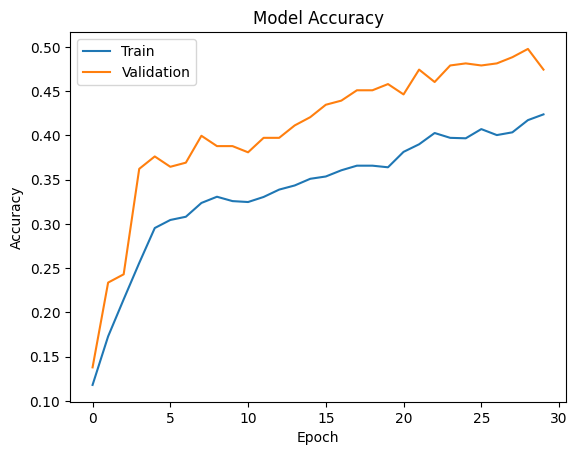

In [26]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Evaluate the model on test data**

In [30]:
#accuracy = model1.evaluate(______, ______, verbose=2)    # Complete the code to evaluate the model on test data
#accuracy = model1.evaluate(X_test, y_test, verbose=2)
accuracy = model1.evaluate(X_test_normalized, y_test_encoded, verbose=2)  # Use y_test_encoded instead of y_test

15/15 - 1s - 53ms/step - accuracy: 0.4842 - loss: 1.5461


In [31]:
accuracy = model1.evaluate(X_test_normalized, y_test_encoded, verbose=2)  # Use y_test_encoded instead of y_test

15/15 - 0s - 6ms/step - accuracy: 0.4842 - loss: 1.5461


**Plotting the Confusion Matrix**

In [32]:
# Here we would get the output as probablities for each category
#y_pred=model1.predict(______)                          # Complete the code to predict the output probabilities

y_pred = model1.predict(X_test)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


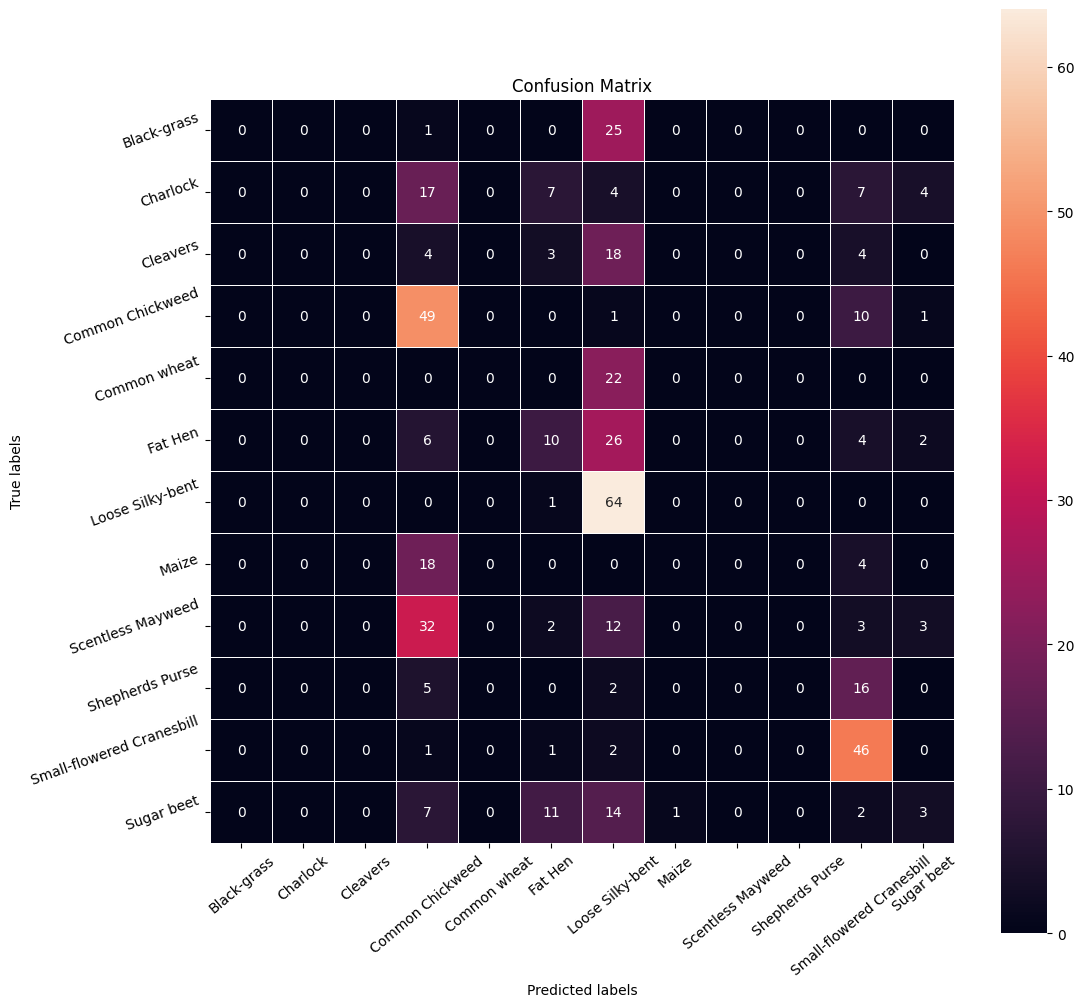

In [33]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred,axis=1)
y_test_arg=np.argmax(y_test_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined in tensorflow module
# confusion_matrix = tf.math.confusion_matrix(______,______)              # Complete the code to plot the confusion matrix
# f, ax = plt.subplots(figsize=(12, 12))
# sns.heatmap(
#     confusion_matrix,
#     annot=True,
#     linewidths=.4,
#     fmt="d",
#     square=True,
#     ax=ax
# )
# # Setting the labels to both the axes
# ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
# ax.set_title('Confusion Matrix');
# ax.xaxis.set_ticklabels(list(enc.classes_),rotation=40)
# ax.yaxis.set_ticklabels(list(enc.classes_),rotation=20)
# plt.show()

# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg = np.argmax(y_pred, axis=1)
y_test_arg = np.argmax(y_test_encoded, axis=1)

# Plotting the Confusion Matrix using confusion_matrix() function from tensorflow
confusion_matrix = tf.math.confusion_matrix(y_test_arg, y_pred_arg)

# Plotting the heatmap for the confusion matrix
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)

# Setting the labels to both the axes
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')

# Assuming 'enc' is your label encoder, you can use the class labels for the axes
ax.xaxis.set_ticklabels(list(enc.classes_), rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_), rotation=20)

plt.show()


**Plotting Classification Report**

In [43]:
# Plotting the classification report
#cr=metrics.classification_report(_______,_______)     # Complete the code to plot the classification report
# cr = metrics.classification_report(y_test_arg, y_pred_arg)
# print(cr)

In [46]:
# Importing the classification_report from sklearn.metrics
from sklearn.metrics import classification_report

# Plotting the classification report
# cr=metrics.classification_report(_______,_______)     # Complete the code to plot the classification report
cr = classification_report(y_test_arg, y_pred_arg)  # Using classification_report directly
print(cr)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.00      0.00      0.00        39
           2       0.00      0.00      0.00        29
           3       0.35      0.80      0.49        61
           4       0.00      0.00      0.00        22
           5       0.29      0.21      0.24        48
           6       0.34      0.98      0.50        65
           7       0.00      0.00      0.00        22
           8       0.00      0.00      0.00        52
           9       0.00      0.00      0.00        23
          10       0.48      0.92      0.63        50
          11       0.23      0.08      0.12        38

    accuracy                           0.36       475
   macro avg       0.14      0.25      0.16       475
weighted avg       0.19      0.36      0.23       475



## Model Performance Improvement

**Reducing the Learning Rate:**

**ReduceLRonPlateau()** is a function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

In [47]:
# Code to monitor val_accuracy
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)


### **Data Augmentation**

In [45]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [48]:
# Complete the code to set the rotation_range to 20
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest'
                              )

In [44]:
# # Intializing a sequential model
# model2 = Sequential()

# # Complete the code to add the first conv layer with 64 filters and kernel size 3x3 , padding 'same' provides the output size same as the input size
# # Input_shape denotes input image dimension images
# model2.add(______(64, (______, ______), activation='relu', padding="same", input_shape=(64, 64, 3)))

# # Complete the code to add max pooling to reduce the size of output of first conv layer
# model2.add(______((2, 2), padding = 'same'))


# model2.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
# model2.add(MaxPooling2D((2, 2), padding = 'same'))
# model2.add(BatchNormalization())

# # flattening the output of the conv layer after max pooling to make it ready for creating dense connections
# model2.add(Flatten())

# # Adding a fully connected dense layer with 16 neurons
# model2.add(Dense(16, activation='relu'))

# # Complete the code to add dropout with dropout_rate=0.3
# model2.add(Dropout(______))
# # Complete the code to add the output layer with 12 neurons and activation functions as softmax since this is a multi-class classification problem
# model2.add(Dense(12, activation='______'))

# # Complete the code to initialize Adam Optimimzer
# opt=______
# # Complete the code to Compile model
# model2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# # Generating the summary of the model
# model2.______()

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam

# Initializing a sequential model
model2 = Sequential()

# Adding the first conv layer with 64 filters and kernel size 3x3, padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension (64, 64, 3)
model2.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 3)))

# Adding max pooling to reduce the size of output of the first conv layer
model2.add(MaxPooling2D((2, 2), padding='same'))

# Adding additional convolution, max-pooling, and batch normalization layers
model2.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model2.add(MaxPooling2D((2, 2), padding='same'))
model2.add(BatchNormalization())

# Flattening the output of the conv layer after max pooling to make it ready for creating dense connections
model2.add(Flatten())

# Adding a fully connected dense layer with 16 neurons
model2.add(Dense(16, activation='relu'))

# Adding dropout with dropout_rate=0.3 to reduce overfitting
model2.add(Dropout(0.3))

# Adding the output layer with 12 neurons and activation function as softmax for multi-class classification
model2.add(Dense(12, activation='softmax'))

# Initializing Adam Optimizer
opt = Adam()

# Compiling the model with categorical crossentropy loss for multi-class classification
model2.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │         131,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,676 (592.48 KB)

 Trainable params: 151,612 (592.23 KB)

 Non-trainable params: 64 (256.00 B)

<b> Fitting the model on the train data

In [49]:
# Complete the code to fit the model on train data with batch_size=64 and epochs=30
# Epochs
# epochs = ______
# # Batch size
# batch_size = ______

# history = model2.fit(train_datagen.flow(______,y_train_encoded,
#                                        batch_size=batch_size,
#                                        shuffle=False),
#                                        epochs=epochs,
#                                        steps_per_epoch=X_train_normalized.shape[0] // batch_size,
#                                        validation_data=(X_val_normalized,y_val_encoded),
#                                        verbose=1,callbacks=[learning_rate_reduction])

# Epochs
epochs = 30

# Batch size
batch_size = 64

history = model2.fit(
    train_datagen.flow(X_train_normalized, y_train_encoded,
                       batch_size=batch_size,
                       shuffle=True),  # shuffle=True for better training performance
    epochs=epochs,
    steps_per_epoch=X_train_normalized.shape[0] // batch_size,
    validation_data=(X_val_normalized, y_val_encoded),
    verbose=1,
    callbacks=[learning_rate_reduction]
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 152ms/step - accuracy: 0.1854 - loss: 2.3597 - val_accuracy: 0.0818 - val_loss: 2.4350 - learning_rate: 0.0010
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - accuracy: 0.3438 - loss: 2.0480 - val_accuracy: 0.0818 - val_loss: 2.4393 - learning_rate: 0.0010
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.3434 - loss: 1.8996 - val_accuracy: 0.1846 - val_loss: 2.3437 - learning_rate: 0.0010
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 944us/step - accuracy: 0.3281 - loss: 1.6846 - val_accuracy: 0.1822 - val_loss: 2.3423 - learning_rate: 0.0010
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.4252 - loss: 1.6433 - val_accuracy: 0.3575 - val_loss: 2.1885 - learning_rate: 0.0010
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4375 - loss: 1.5146 - val_accuracy: 0.3995 - val_loss: 2.1660 - learning_rate: 0.0010
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.4892 - loss: 1.4914 - val

**Model Evaluation**

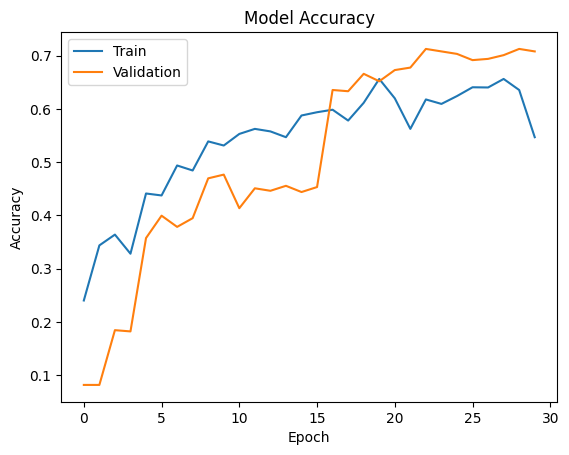

In [50]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

**Evaluate the model on test data**

In [51]:
#accuracy = model2.evaluate(______, y_test_encoded, verbose=2)  # Complete the code to evaluate the model on test data
accuracy = model2.evaluate(X_test_normalized, y_test_encoded, verbose=2)

15/15 - 1s - 50ms/step - accuracy: 0.6926 - loss: 0.9506


**Plotting the Confusion Matrix**

In [52]:
# Complete the code to obtain the output probabilities
#y_pred=model2.predict(______)
y_pred = model2.predict(X_test_normalized)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


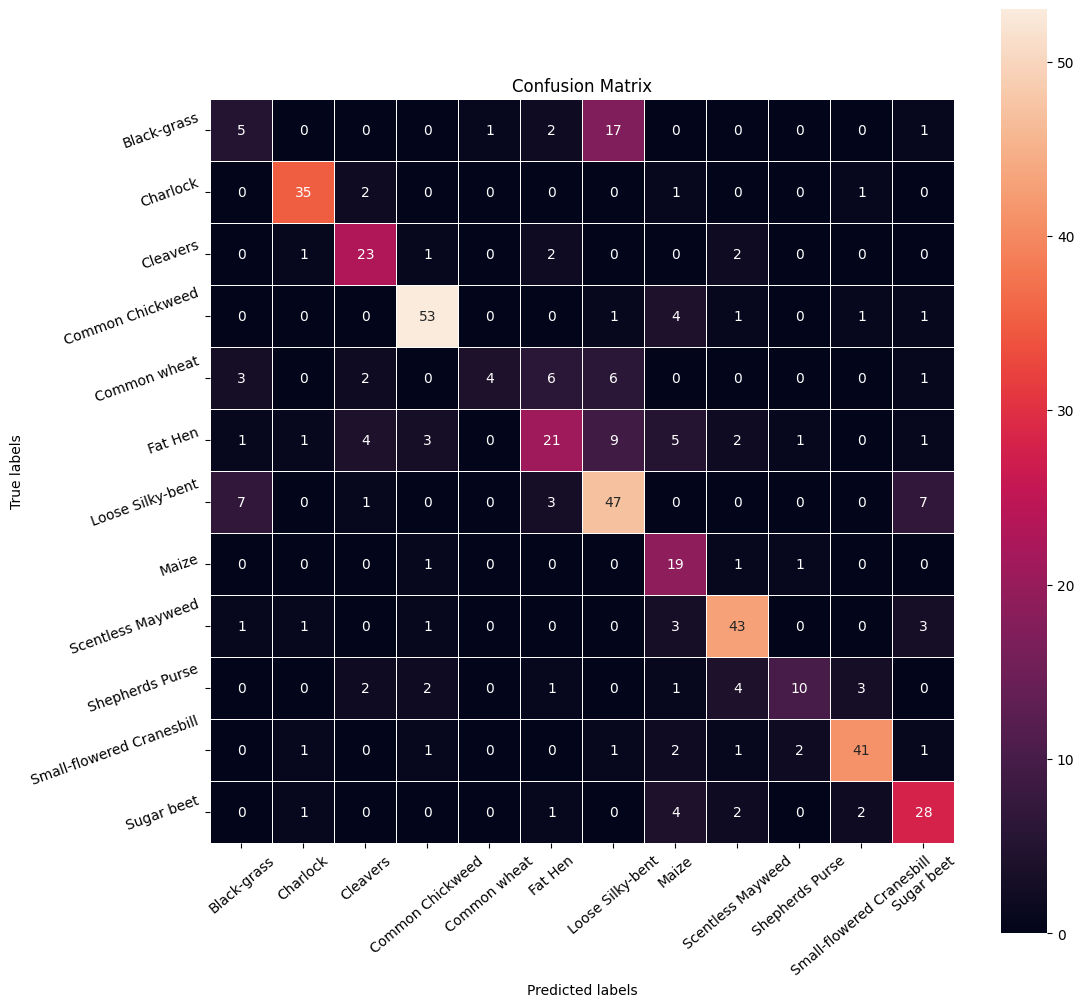

In [53]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred,axis=1)
y_test_arg=np.argmax(y_test_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined in tensorflow module
#confusion_matrix = tf.math.confusion_matrix(______,y_pred_arg)     # Complete the code to obatin the confusion matrix
confusion_matrix = tf.math.confusion_matrix(y_test_arg, y_pred_arg)
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=40)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=20)
plt.show()

**Plotting Classification Report**

In [42]:
# Importing the classification_report from sklearn.metrics
# from sklearn.metrics import classification_report

# # Plotting the classification report
# #cr=metrics.classification_report(_______,_______)     # Complete the code to plot the classification report
# cr = metrics.classification_report(y_test_arg, y_pred_arg)
# print(cr)

In [54]:
# Importing the classification_report from sklearn.metrics
from sklearn.metrics import classification_report

# Plotting the classification report
#cr=metrics.classification_report(_______,_______)     # Complete the code to plot the classification report
cr = classification_report(y_test_arg, y_pred_arg)  # Using classification_report directly
print(cr)

              precision    recall  f1-score   support

           0       0.29      0.19      0.23        26
           1       0.88      0.90      0.89        39
           2       0.68      0.79      0.73        29
           3       0.85      0.87      0.86        61
           4       0.80      0.18      0.30        22
           5       0.58      0.44      0.50        48
           6       0.58      0.72      0.64        65
           7       0.49      0.86      0.62        22
           8       0.77      0.83      0.80        52
           9       0.71      0.43      0.54        23
          10       0.85      0.82      0.84        50
          11       0.65      0.74      0.69        38

    accuracy                           0.69       475
   macro avg       0.68      0.65      0.64       475
weighted avg       0.70      0.69      0.68       475



In [55]:
# Importing the classification_report from sklearn.metrics
from sklearn.metrics import classification_report

# Plotting the classification report
#cr=metrics.classification_report(_______,_______)     # Complete the code to plot the classification report
cr = classification_report(y_test_arg, y_pred_arg)  # Using classification_report directly
print(cr)

              precision    recall  f1-score   support

           0       0.29      0.19      0.23        26
           1       0.88      0.90      0.89        39
           2       0.68      0.79      0.73        29
           3       0.85      0.87      0.86        61
           4       0.80      0.18      0.30        22
           5       0.58      0.44      0.50        48
           6       0.58      0.72      0.64        65
           7       0.49      0.86      0.62        22
           8       0.77      0.83      0.80        52
           9       0.71      0.43      0.54        23
          10       0.85      0.82      0.84        50
          11       0.65      0.74      0.69        38

    accuracy                           0.69       475
   macro avg       0.68      0.65      0.64       475
weighted avg       0.70      0.69      0.68       475



## Final Model

Comment on the final model you have selected and use the same in the below code to visualize the image.

### Visualizing the prediction

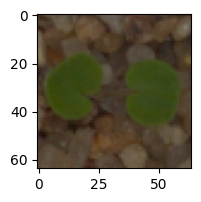

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicted Label: ['Black-grass']
True Label: Small-flowered Cranesbill


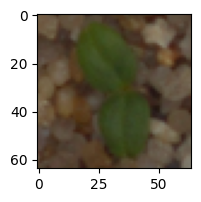

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted Label: ['Black-grass']
True Label: Cleavers


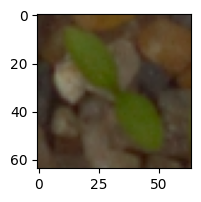

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Predicted Label: ['Black-grass']
True Label: Common Chickweed


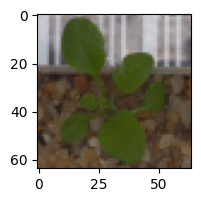

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Predicted Label: ['Black-grass']
True Label: Shepherds Purse


In [62]:

# # Visualizing the predicted and correct label of images from test data
# plt.figure(figsize=(2,2))
# plt.imshow(X_test[2])
# plt.show()
# ## Complete the code to predict the test data using the final model selected
# print('Predicted Label', enc.inverse_transform(_____.predict((X_test_normalized[2].reshape(1,64,64,3)))))   # reshaping the input image as we are only trying to predict using a single image
# print('True Label', enc.inverse_transform(y_test_encoded)[2])                                               # using inverse_transform() to get the output label from the output vector

# plt.figure(figsize=(2,2))
# plt.imshow(X_test[33])
# plt.show()
# ## Complete the code to predict the test data using the final model selected
# print('Predicted Label', enc.inverse_transform(_______.predict((X_test_normalized[33].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
# print('True Label', enc.inverse_transform(y_test_encoded)[33])                                              # using inverse_transform() to get the output label from the output vector

# plt.figure(figsize=(2,2))
# plt.imshow(X_test[59],)
# plt.show()
# ## Complete the code to predict the test data using the final model selected
# print('Predicted Label', enc.inverse_transform(________.predict((X_test_normalized[59].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
# print('True Label', enc.inverse_transform(y_test_encoded)[59])                                              # using inverse_transform() to get the output label from the output vector

# plt.figure(figsize=(2,2))
# plt.imshow(X_test[36])
# plt.show()
# ## Complete the code to predict the test data using the final model selected
# print('Predicted Label', enc.inverse_transform(______.predict((X_test_normalized[36].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
# print('True Label', enc.inverse_transform(y_test_encoded)[36])                                              # using inverse_transform() to get the output label from the output vector

import matplotlib.pyplot as plt

# Visualizing the predicted and correct label of images from test data

# Plotting the first image
plt.figure(figsize=(2, 2))
plt.imshow(X_test[2])
plt.show()

# # Predicting the label for the 3rd image (index 2)
# print('Predicted Label:', enc.inverse_transform(np.argmax(model2.predict(X_test_normalized[2].reshape(1, 64, 64, 3)), axis=1)))
# print('True Label:', enc.inverse_transform(y_test_encoded)[2])

# Predicting the label for the 3rd image (index 2)
print('Predicted Label:', enc.inverse_transform(np.argmax(model2.predict(X_test_normalized[2].reshape(1, 64, 64, 3)), axis=1).reshape(-1, 1))) # Reshape to 2D
print('True Label:', enc.inverse_transform(y_test_encoded)[2])


# Plotting the 34th image
plt.figure(figsize=(2, 2))
plt.imshow(X_test[33])
plt.show()

# Predicting the label for the 34th image (index 33)
print('Predicted Label:', enc.inverse_transform(np.argmax(model2.predict(X_test_normalized[33].reshape(1, 64, 64, 3)), axis=1).reshape(-1, 1)))
print('True Label:', enc.inverse_transform(y_test_encoded)[33])

# Plotting the 60th image
plt.figure(figsize=(2, 2))
plt.imshow(X_test[59])
plt.show()

# Predicting the label for the 60th image (index 59)
print('Predicted Label:', enc.inverse_transform(np.argmax(model2.predict(X_test_normalized[59].reshape(1, 64, 64, 3)), axis=1).reshape(-1, 1)))
print('True Label:', enc.inverse_transform(y_test_encoded)[59])

# Plotting the 37th image
plt.figure(figsize=(2, 2))
plt.imshow(X_test[36])
plt.show()

# Predicting the label for the 37th image (index 36)
print('Predicted Label:', enc.inverse_transform(np.argmax(model2.predict(X_test_normalized[36].reshape(1, 64, 64, 3)), axis=1).reshape(-1, 1)))
print('True Label:', enc.inverse_transform(y_test_encoded)[36])


## Actionable Insights and Business Recommendations

*

_____